In [1]:
print("Here begins the data overview notebook.")

Here begins the data overview notebook.


In [2]:
# World Happiness Report (2024) – Data Overview & Preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load dataset, set display options, show first few rows
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/world_happiness/world_happiness_report.csv")
df.head()

,Country,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception,Unemployment_Rate,Education_Index,Population,Urbanization_Rate,Life_Satisfaction,Public_Trust,Mental_Health_Index,Income_Inequality,Public_Health_Expenditure,Climate_Index,Work_Life_Balance,Internet_Access,Crime_Rate,Political_Stability,Employment_Rate
0,China,2022,4.39,44984.68,0.53,71.11,0.41,-0.05,0.83,14.98,0.52,1311940760,78.71,8.88,0.34,76.44,46.06,8.92,62.75,8.59,74.40,70.30,0.29,61.38
1,UK,2015,5.49,30814.59,0.93,63.14,0.89,0.04,0.84,19.46,0.83,1194240877,50.87,5.03,0.72,53.38,46.43,4.43,53.11,8.76,91.74,73.32,0.76,80.18
2,Brazil,2009,4.65,39214.84,0.03,62.36,0.01,0.16,0.59,16.68,0.95,731100898,48.75,5.22,0.23,82.40,31.03,3.78,33.30,6.06,71.80,28.99,0.94,72.65
3,France,2019,5.20,30655.75,0.77,78.94,0.98,0.25,0.63,2.64,0.70,1293957314,81.78,5.69,0.68,46.87,57.65,4.43,90.59,6.36,86.16,45.76,0.48,55.14
4,China,2022,7.28,30016.87,0.05,50.33,0.62,0.18,0.92,7.70,0.92,1432971455,82.39,6.33,0.50,60.38,28.54,7.66,59.33,3.00,71.10,65.67,0.12,51.55


In [3]:
#Print information about the dataset
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)

Shape: (4000, 24)

Column types:
Country                          str
Year                           int64
Happiness_Score              float64
GDP_per_Capita               float64
Social_Support               float64
Healthy_Life_Expectancy      float64
Freedom                      float64
Generosity                   float64
Corruption_Perception        float64
Unemployment_Rate            float64
Education_Index              float64
Population                     int64
Urbanization_Rate            float64
Life_Satisfaction            float64
Public_Trust                 float64
Mental_Health_Index          float64
Income_Inequality            float64
Public_Health_Expenditure    float64
Climate_Index                float64
Work_Life_Balance            float64
Internet_Access              float64
Crime_Rate                   float64
Political_Stability          float64
Employment_Rate              float64
dtype: object


In [4]:
#Print summary statistics
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,4000,10,USA,429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,4000.0,NaN,NaN,NaN,2014.67075,5.724075,2005.0,2010.0,2015.0,2020.0,2024.0
Happiness_Score,4000.0,NaN,NaN,NaN,5.455005,1.42737,3.0,4.2375,5.43,6.6625,8.0
GDP_per_Capita,4000.0,NaN,NaN,NaN,30482.009953,17216.122032,1009.31,15425.125,29991.255,45763.085,59980.72
Social_Support,4000.0,NaN,NaN,NaN,0.50586,0.286202,0.0,0.26,0.51,0.75,1.0
Healthy_Life_Expectancy,4000.0,NaN,NaN,NaN,67.917605,10.172091,50.0,59.1775,68.015,76.69,85.0
Freedom,4000.0,NaN,NaN,NaN,0.502723,0.285219,0.0,0.26,0.5,0.75,1.0
Generosity,4000.0,NaN,NaN,NaN,0.14396,0.200088,-0.2,-0.03,0.14,0.31,0.5
Corruption_Perception,4000.0,NaN,NaN,NaN,0.49892,0.288866,0.0,0.24,0.5,0.7425,1.0
Unemployment_Rate,4000.0,NaN,NaN,NaN,10.966748,5.210712,2.0,6.45,10.995,15.45,19.99


In [5]:
# Variable semantics, save summary to CSV
variable_summary = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique()
})

variable_summary.sort_values("missing_pct", ascending=False)
variable_summary.to_csv("../outputs/tables/world_happiness_report_variable_summary.csv", index=False)

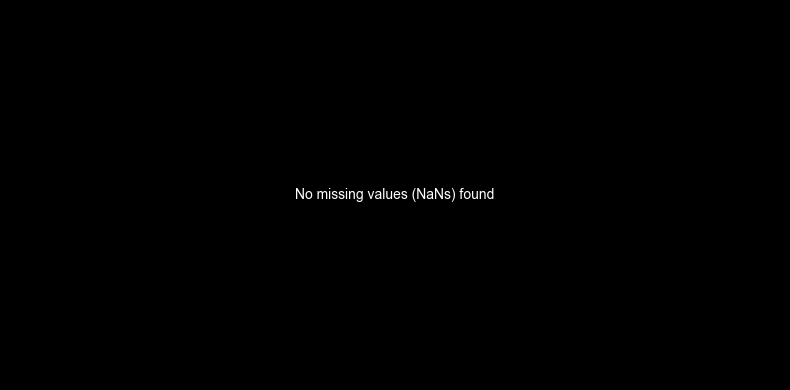

In [7]:
# Missing data analysis
missing = df.isna().mean().sort_values(ascending=False)
missing_nonzero = missing[missing > 0]

plt.figure(figsize=(8,4))

if missing_nonzero.empty:
    plt.text(0.5, 0.5, "No missing values (NaNs) found", ha="center", va="center")
    plt.axis("off")
else:
    missing_nonzero.plot(kind="bar")
    plt.ylabel("Missing fraction")
    plt.title("Missing data per variable")

plt.tight_layout()
plt.show()


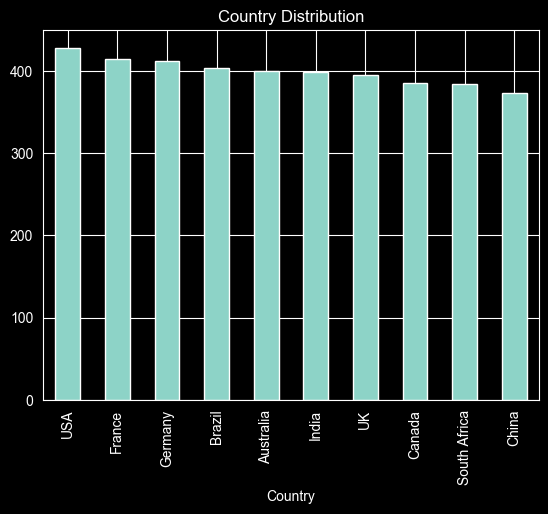

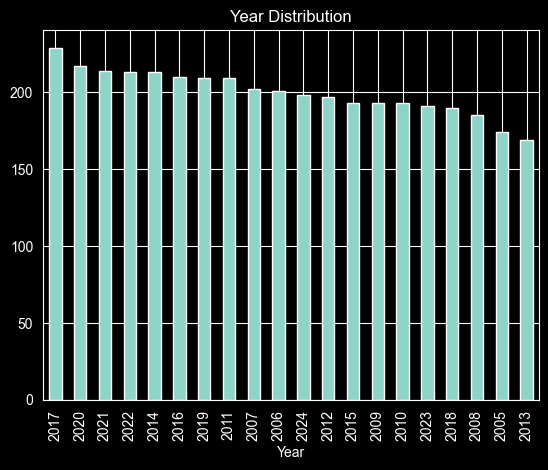

In [5]:
# Exploratory Plots

# Country distribution
df["Country"].value_counts().plot(kind="bar")
plt.title("Country Distribution")
plt.xlabel("Country")
plt.show()


# Year distribution
df["Year"].value_counts().plot(kind="bar")
plt.title("Year Distribution")
plt.xlabel("Year")
plt.show()


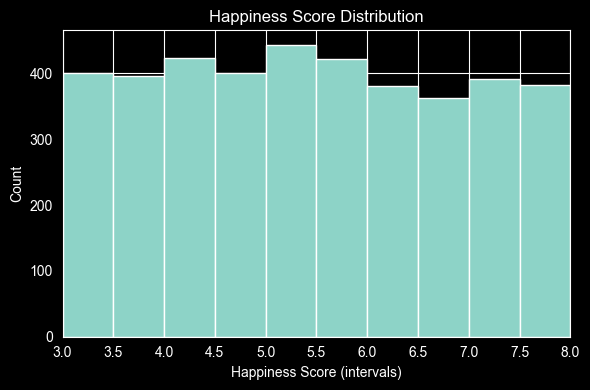

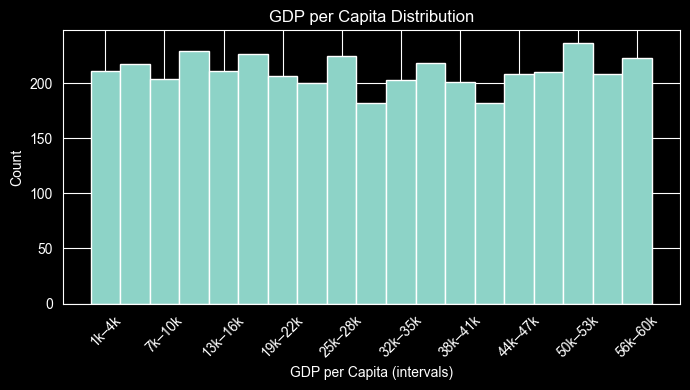

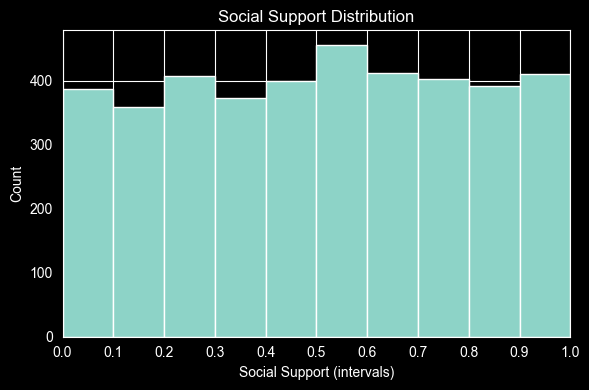

In [13]:
# Happiness Score
bins = np.arange(3, 8.5, 0.5)   # interval edges

plt.figure(figsize=(6,4))
plt.hist(df["Happiness_Score"], bins=bins)

plt.title("Happiness Score Distribution")
plt.xlabel("Happiness Score (intervals)")
plt.ylabel("Count")

plt.xticks(np.arange(3, 8.5, 0.5))
plt.xlim(3, 8)

plt.tight_layout()
plt.show()


# GDP per capita
bins = np.linspace(1000, 60000, 20)
counts, edges = np.histogram(df["GDP_per_Capita"], bins=bins)
centers = (edges[:-1] + edges[1:]) / 2
labels = [f"{int(edges[i]/1000)}k–{int(edges[i+1]/1000)}k"
          for i in range(len(edges) - 1)]
plt.figure(figsize=(7,4))
plt.hist(df["GDP_per_Capita"], bins=bins)
plt.xticks(centers[::2], labels[::2], rotation=45)
plt.title("GDP per Capita Distribution")
plt.xlabel("GDP per Capita (intervals)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Social support
bins = np.linspace(0, 1, 11)
plt.figure(figsize=(6,4))
plt.hist(df["Social_Support"], bins=bins)
plt.title("Social Support Distribution")
plt.xlabel("Social Support (intervals)")
plt.ylabel("Count")
plt.xticks(np.linspace(0, 1, 11))
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


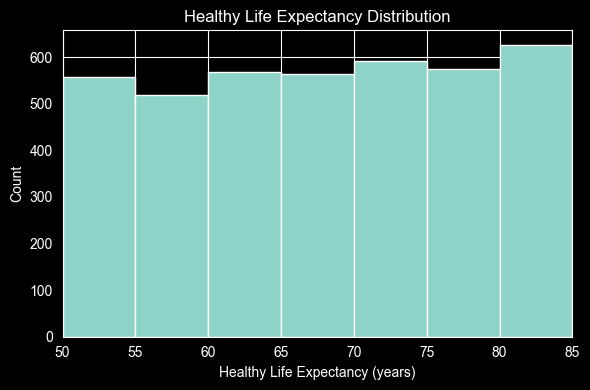

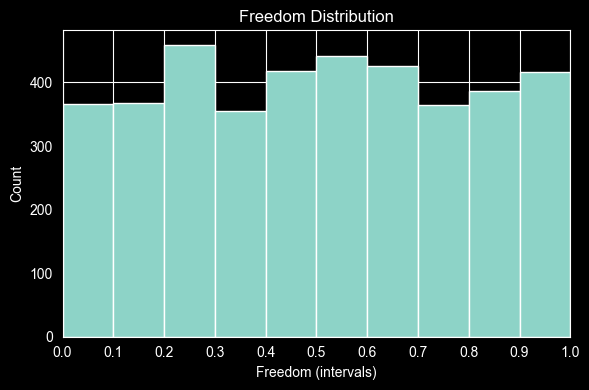

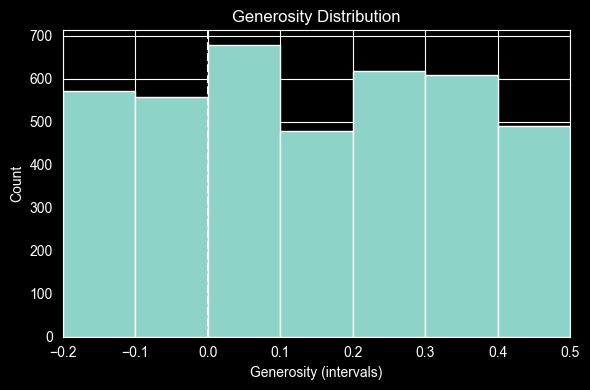

In [17]:
# Healthy life expectancy
bins = np.arange(50, 90, 5)
plt.figure(figsize=(6,4))
plt.hist(df["Healthy_Life_Expectancy"], bins=bins)
plt.title("Healthy Life Expectancy Distribution")
plt.xlabel("Healthy Life Expectancy (years)")
plt.ylabel("Count")
plt.xticks(bins)
plt.xlim(50, 85)
plt.tight_layout()
plt.show()


# Freedom to make life choices
bins = np.linspace(0, 1, 11)
plt.figure(figsize=(6,4))
plt.hist(df["Freedom"], bins=bins)
plt.title("Freedom Distribution")
plt.xlabel("Freedom (intervals)")
plt.ylabel("Count")
plt.xticks(np.linspace(0, 1, 11))
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


# Generosity
bins = np.arange(-0.2, 0.51, 0.1)
plt.figure(figsize=(6,4))
plt.hist(df["Generosity"], bins=bins)
plt.title("Generosity Distribution")
plt.xlabel("Generosity (intervals)")
plt.ylabel("Count")
plt.xticks(np.arange(-0.2, 0.6, 0.1))
plt.xlim(-0.2, 0.5)
plt.axvline(0, linestyle="--")
plt.tight_layout()
plt.show()

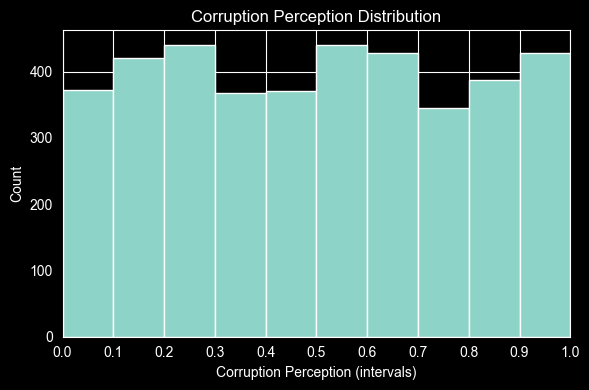

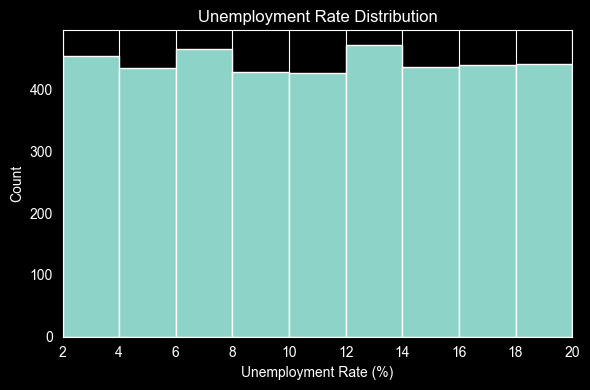

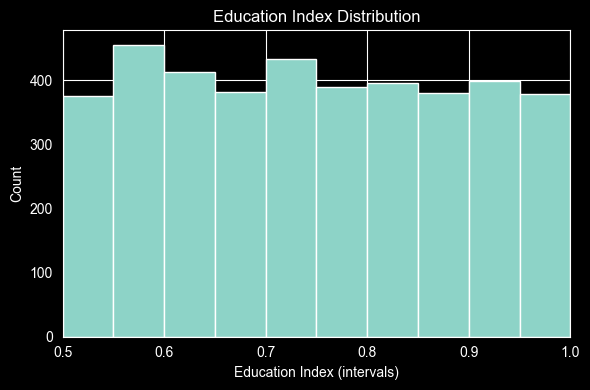

In [21]:
# Corruption
bins = np.linspace(0, 1, 11)
plt.figure(figsize=(6,4))
plt.hist(df["Corruption_Perception"], bins=bins)
plt.title("Corruption Perception Distribution")
plt.xlabel("Corruption Perception (intervals)")
plt.ylabel("Count")
plt.xticks(np.linspace(0, 1, 11))
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


# Unemployment rate
bins = np.arange(2, 22, 2)
plt.figure(figsize=(6,4))
plt.hist(df["Unemployment_Rate"], bins=bins)
plt.title("Unemployment Rate Distribution")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Count")
plt.xticks(bins)
plt.xlim(2, 20)
plt.tight_layout()
plt.show()


# Education Index
bins = np.arange(0.5, 1.01, 0.05)
plt.figure(figsize=(6,4))
plt.hist(df["Education_Index"], bins=bins)
plt.title("Education Index Distribution")
plt.xlabel("Education Index (intervals)")
plt.ylabel("Count")
plt.xticks(np.arange(0.5, 1.01, 0.1))
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

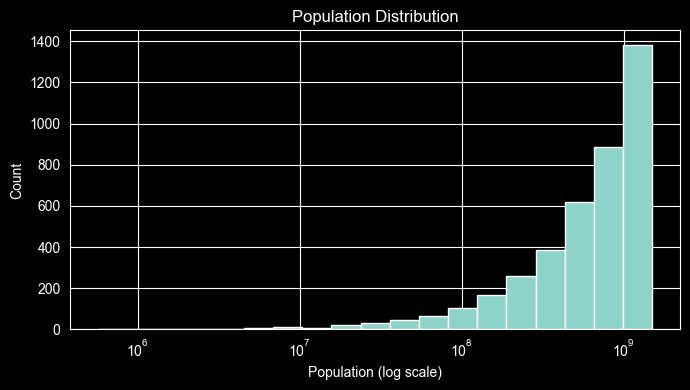

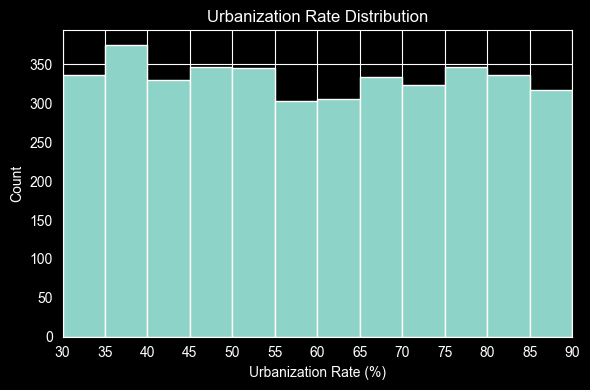

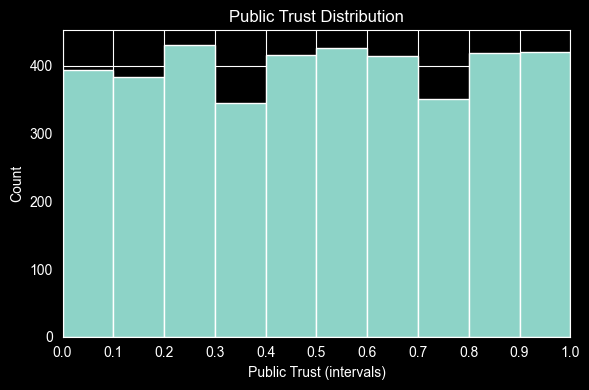

In [25]:
# Population
bins = np.logspace(np.log10(5.7e5), np.log10(1.5e9), 20)
plt.figure(figsize=(7,4))
plt.hist(df["Population"], bins=bins)
plt.xscale("log")
plt.title("Population Distribution")
plt.xlabel("Population (log scale)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Urbanization rate
bins = np.arange(30, 95, 5)
plt.figure(figsize=(6,4))
plt.hist(df["Urbanization_Rate"], bins=bins)
plt.title("Urbanization Rate Distribution")
plt.xlabel("Urbanization Rate (%)")
plt.ylabel("Count")
plt.xticks(bins)
plt.xlim(30, 90)
plt.tight_layout()
plt.show()


# Trust in public institutions
bins = np.linspace(0, 1, 11)
plt.figure(figsize=(6,4))
plt.hist(df["Public_Trust"], bins=bins)
plt.title("Public Trust Distribution")
plt.xlabel("Public Trust (intervals)")
plt.ylabel("Count")
plt.xticks(np.linspace(0, 1, 11))
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

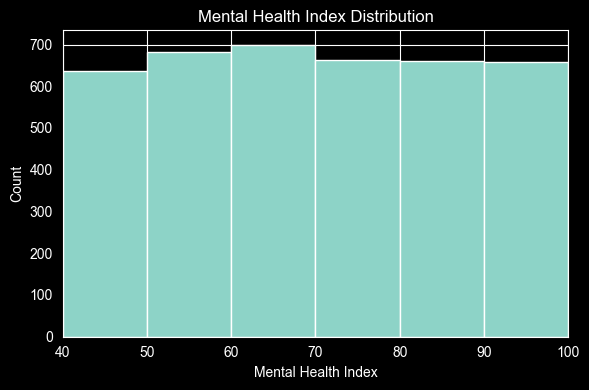

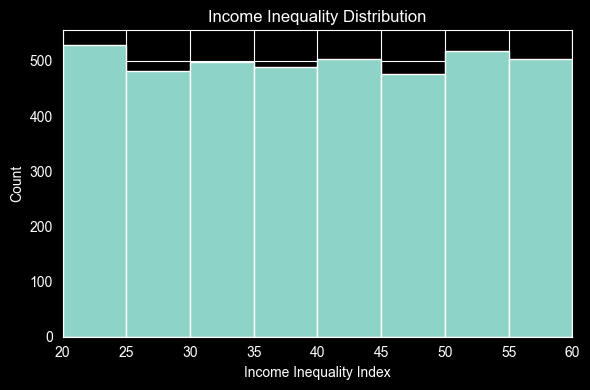

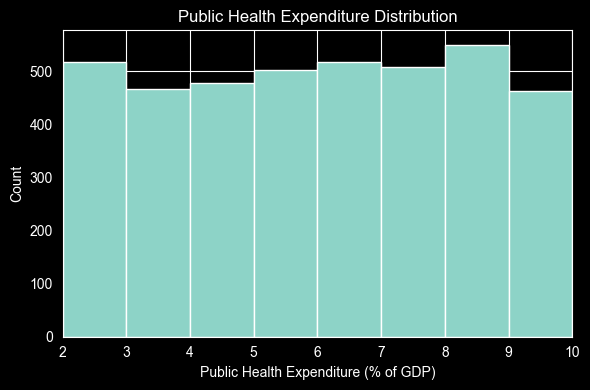

In [29]:
# Mental health index
bins = np.arange(40, 110, 10)
plt.figure(figsize=(6,4))
plt.hist(df["Mental_Health_Index"], bins=bins)
plt.title("Mental Health Index Distribution")
plt.xlabel("Mental Health Index")
plt.ylabel("Count")
plt.xticks(bins)
plt.xlim(40, 100)
plt.tight_layout()
plt.show()


# Income inequality
bins = np.arange(20, 65, 5)
plt.figure(figsize=(6,4))
plt.hist(df["Income_Inequality"], bins=bins)
plt.title("Income Inequality Distribution")
plt.xlabel("Income Inequality Index")
plt.ylabel("Count")
plt.xticks(bins)
plt.xlim(20, 60)
plt.tight_layout()
plt.show()


# Public health index
bins = np.arange(2, 11, 1)
plt.figure(figsize=(6,4))
plt.hist(df["Public_Health_Expenditure"], bins=bins)
plt.title("Public Health Expenditure Distribution")
plt.xlabel("Public Health Expenditure (% of GDP)")
plt.ylabel("Count")
plt.xticks(bins)
plt.xlim(2, 10)
plt.tight_layout()
plt.show()

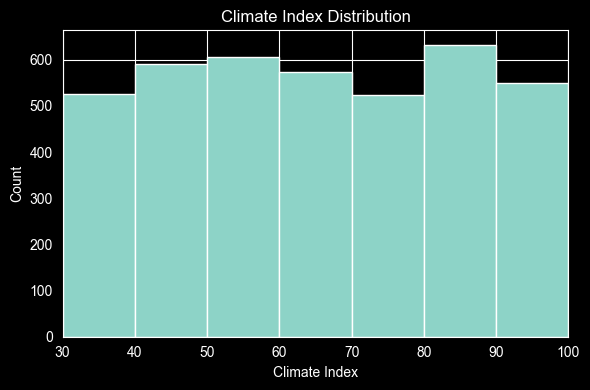

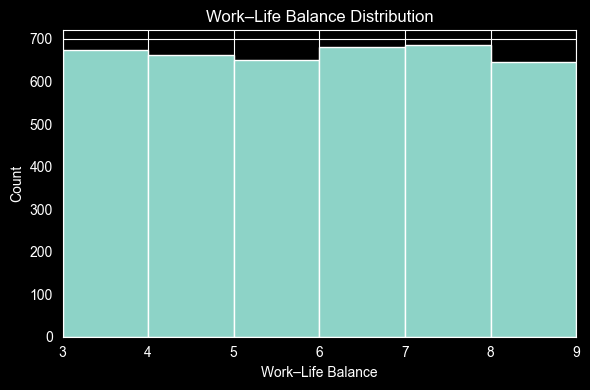

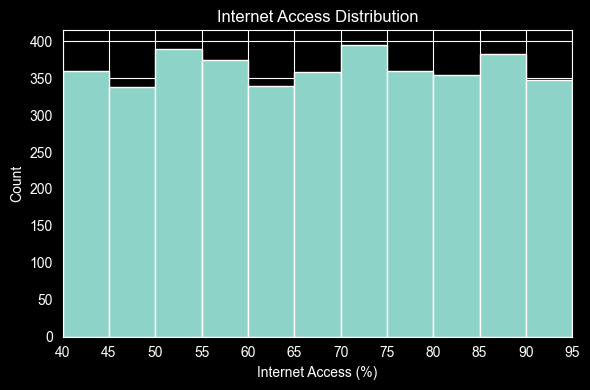

In [32]:
# Climate index
bins = np.arange(30, 110, 10)
plt.figure(figsize=(6,4))
plt.hist(df["Climate_Index"], bins=bins)
plt.title("Climate Index Distribution")
plt.xlabel("Climate Index")
plt.ylabel("Count")
plt.xticks(bins)
plt.xlim(30, 100)
plt.tight_layout()
plt.show()


# Work-life balance
bins = np.arange(3, 10, 1)
plt.figure(figsize=(6,4))
plt.hist(df["Work_Life_Balance"], bins=bins)
plt.title("Work–Life Balance Distribution")
plt.xlabel("Work–Life Balance")
plt.ylabel("Count")
plt.xticks(bins)
plt.xlim(3, 9)
plt.tight_layout()
plt.show()


# Internet access
bins = np.arange(40, 100, 5)
plt.figure(figsize=(6,4))
plt.hist(df["Internet_Access"], bins=bins)
plt.title("Internet Access Distribution")
plt.xlabel("Internet Access (%)")
plt.ylabel("Count")
plt.xticks(bins)
plt.xlim(40, 95)
plt.tight_layout()
plt.show()

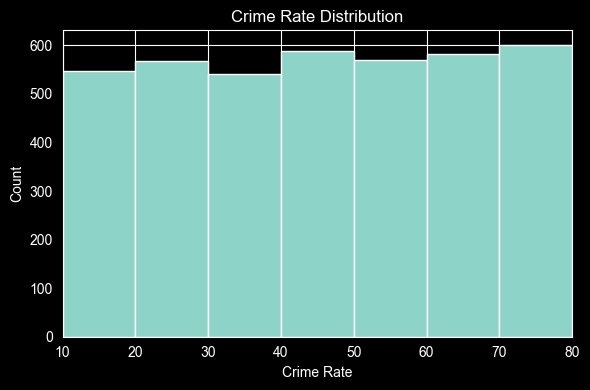

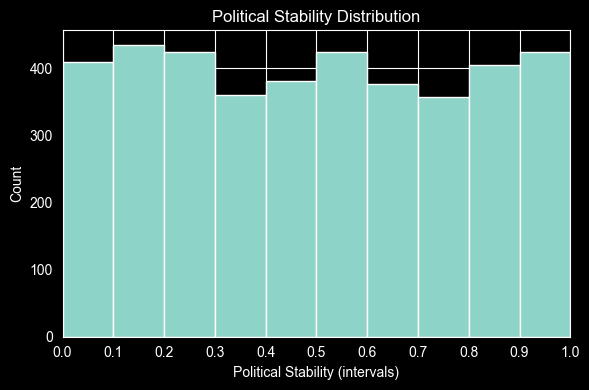

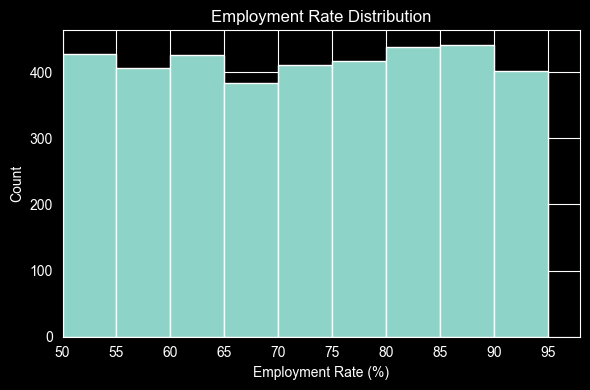

In [35]:
# Crime Rate
bins = np.arange(10, 90, 10)
plt.figure(figsize=(6,4))
plt.hist(df["Crime_Rate"], bins=bins)
plt.title("Crime Rate Distribution")
plt.xlabel("Crime Rate")
plt.ylabel("Count")
plt.xticks(bins)
plt.xlim(10, 80)
plt.tight_layout()
plt.show()


# Political stability
bins = np.linspace(0, 1, 11)
plt.figure(figsize=(6,4))
plt.hist(df["Political_Stability"], bins=bins)
plt.title("Political Stability Distribution")
plt.xlabel("Political Stability (intervals)")
plt.ylabel("Count")
plt.xticks(np.linspace(0, 1, 11))
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


# Employment rate
bins = np.arange(50, 100, 5)
plt.figure(figsize=(6,4))
plt.hist(df["Employment_Rate"], bins=bins)
plt.title("Employment Rate Distribution")
plt.xlabel("Employment Rate (%)")
plt.ylabel("Count")
plt.xticks(bins)
plt.xlim(50, 98)
plt.tight_layout()
plt.show()

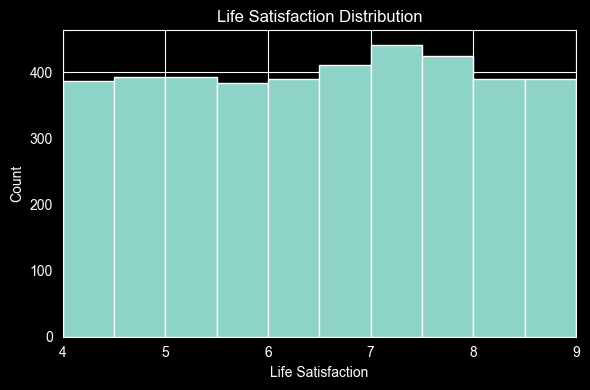

In [37]:
# Life Satisfaction - target variable
bins = np.arange(4, 9.5, 0.5)
plt.figure(figsize=(6,4))
plt.hist(df["Life_Satisfaction"], bins=bins)
plt.xticks(np.arange(4, 10, 1))
plt.xlim(4, 9)
plt.title("Life Satisfaction Distribution")
plt.xlabel("Life Satisfaction")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

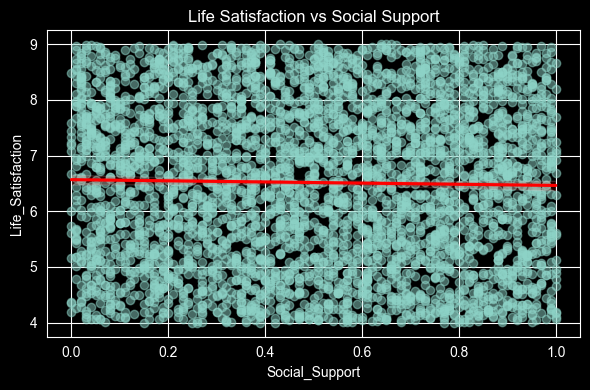

In [38]:
# Relationship with outcome
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.regplot(
    x="Social_Support",
    y="Life_Satisfaction",
    data=df,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title("Life Satisfaction vs Social Support")
plt.tight_layout()
plt.show()